# Baseline depression risk model (Linear Regression)

Using prepared train/test data to build a simple baseline and convert predictions to risk %.

In [41]:
# 1. Imports
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')


In [42]:
# 2. Load the prepared data
train_path = '../Dataset/processed/train_prepared.parquet'
test_path = '../Dataset/processed/test_prepared.parquet'

train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

print(f'train_df shape: {train_df.shape}')
print(f'test_df shape: {test_df.shape}')

display(train_df.head())


train_df shape: (62398, 14)
test_df shape: (15600, 14)


,age,hhsize,partnerinhh,chronic_mod,mobilityind,casp,bmi,adla,grossmotor,sphus,recall_1,smoking,eduyears_mod,eurod
0,0.301402,0.2,0.0,0.6,0.00,0.518519,0.390242,0.0,0.0,0.75,0.444444,1.0,0.55,1.0
1,0.116822,0.0,1.0,0.0,0.00,0.629630,0.333275,0.0,0.0,0.75,0.666667,1.0,0.40,4.0
2,0.598131,0.2,0.0,0.0,0.00,0.518519,0.070852,0.0,0.0,0.50,0.888889,1.0,0.15,4.0
3,0.257009,0.0,1.0,0.0,0.25,0.370370,0.605000,0.2,0.0,0.75,0.777778,0.0,0.50,5.0
4,0.306075,0.2,0.0,0.2,0.00,0.185185,0.232555,0.0,0.0,0.75,0.555556,0.0,0.10,4.0


In [43]:
# 3. Define target and feature list
feature_cols = [
    'age',
    'hhsize',
    'partnerinhh',
    'chronic_mod',
    'mobilityind',
    'casp',
    'bmi',
    'adla',
    'grossmotor',
    'sphus',
    'recall_1',
    'smoking',
    'eduyears_mod',
]

X_train = train_df[feature_cols]
y_train = train_df['eurod']
X_test = test_df[feature_cols]
y_test = test_df['eurod']


In [44]:
# 4. Sanity check for missing values
missing_counts = {
    'X_train': int(X_train.isnull().sum().sum()),
    'y_train': int(y_train.isnull().sum().sum()),
    'X_test': int(X_test.isnull().sum().sum()),
    'y_test': int(y_test.isnull().sum().sum()),
}

print('Missing values before dropna:')
for name, count in missing_counts.items():
    print(f"{name}: {count}")

if any(missing_counts.values()):
    train_clean = pd.concat([X_train, y_train], axis=1).dropna()
    X_train = train_clean[feature_cols]
    y_train = train_clean['eurod']

    test_clean = pd.concat([X_test, y_test], axis=1).dropna()
    X_test = test_clean[feature_cols]
    y_test = test_clean['eurod']

    print('Dropped rows with missing values.')
else:
    print('No missing values found; continuing with full data.')

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')


Missing values before dropna:
X_train: 0
y_train: 0
X_test: 0
y_test: 0
No missing values found; continuing with full data.
X_train shape: (62398, 13)
X_test shape: (15600, 13)


In [45]:
# 5. Baseline model: Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)


In [46]:
# 6. Convert predictions to risk percentage
y_train_pred_clipped = np.clip(y_train_pred, 0, 12)
y_test_pred_clipped = np.clip(y_test_pred, 0, 12)

train_risk_pct = (y_train_pred_clipped / 12.0) * 100
test_risk_pct = (y_test_pred_clipped / 12.0) * 100


In [47]:
# 7. Evaluate the baseline model numerically
def regression_metrics(y_true, y_pred, label=''):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label}MAE:  {mae:.3f}")
    print(f"{label}RMSE: {rmse:.3f}")
    print(f"{label}R^2:  {r2:.3f}")
    print()

print('=== TRAIN METRICS (eurod) ===')
regression_metrics(y_train, y_train_pred_clipped, label='Train ')

print('=== TEST METRICS (eurod) ===')
regression_metrics(y_test, y_test_pred_clipped, label='Test ')


=== TRAIN METRICS (eurod) ===
Train MAE:  1.446
Train RMSE: 1.822
Train R^2:  0.336

=== TEST METRICS (eurod) ===
Test MAE:  1.445
Test RMSE: 1.822
Test R^2:  0.337



In [48]:
# 8. Create a small results table
results_df = pd.DataFrame({
    'eurod_true': y_test,
    'eurod_pred': y_test_pred_clipped,
    'risk_percent': test_risk_pct
})

display(results_df.head(10))


,eurod_true,eurod_pred,risk_percent
0,4.0,2.553738,21.281153
1,1.0,1.512313,12.602607
2,2.0,0.952026,7.933546
3,1.0,2.578950,21.491251
4,1.0,1.755564,14.629703
5,1.0,2.440910,20.340913
6,2.0,3.239807,26.998390
7,3.0,2.532645,21.105377
8,0.0,1.729055,14.408789
9,4.0,4.375447,36.462056


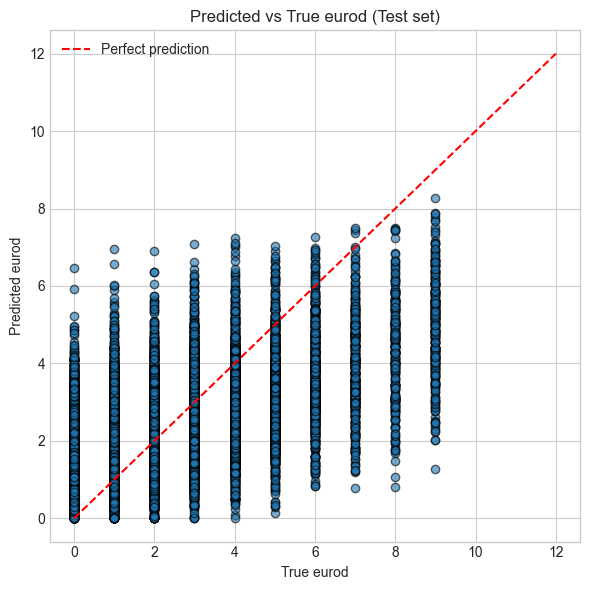

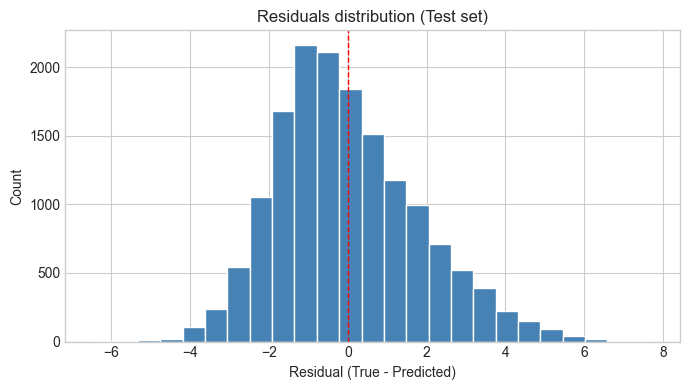

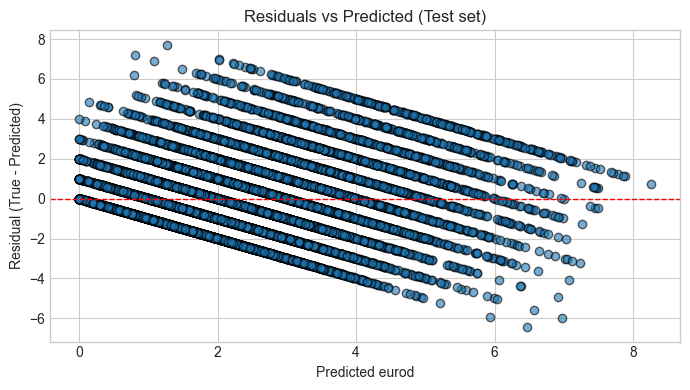

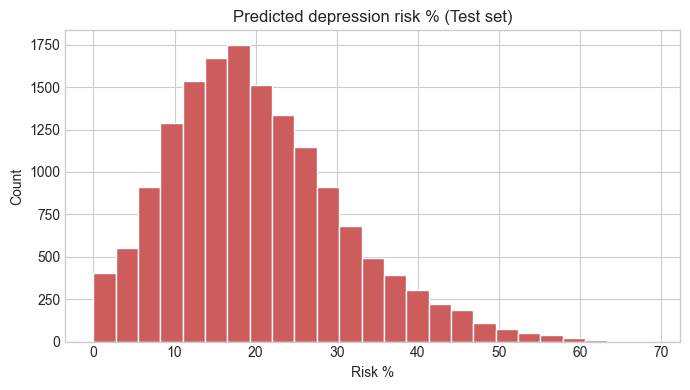

In [49]:
# 9. Plots to visualize model performance
residuals_test = y_test - y_test_pred_clipped

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred_clipped, alpha=0.6, edgecolor='k')
plt.plot([0, 12], [0, 12], 'r--', label='Perfect prediction')
plt.xlabel('True eurod')
plt.ylabel('Predicted eurod')
plt.title('Predicted vs True eurod (Test set)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residuals_test, bins=25, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Residual (True - Predicted)')
plt.ylabel('Count')
plt.title('Residuals distribution (Test set)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(y_test_pred_clipped, residuals_test, alpha=0.6, edgecolor='k')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Predicted eurod')
plt.ylabel('Residual (True - Predicted)')
plt.title('Residuals vs Predicted (Test set)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(test_risk_pct, bins=25, color='indianred', edgecolor='white')
plt.xlabel('Risk %')
plt.ylabel('Count')
plt.title('Predicted depression risk % (Test set)')
plt.tight_layout()
plt.show()


In [50]:
# 10. Short textual interpretation
mae_test = mean_absolute_error(y_test, y_test_pred_clipped)
print(f'Typical absolute error (MAE) is about {mae_test:.2f} points on the 0-12 eurod scale.')
print('This linear regression is a quick screening tool, not a diagnostic decision-maker.')
print('Higher risk_percent values indicate higher predicted depression scores (more risk).')


Typical absolute error (MAE) is about 1.44 points on the 0-12 eurod scale.
This linear regression is a quick screening tool, not a diagnostic decision-maker.
Higher risk_percent values indicate higher predicted depression scores (more risk).


### Notes
- LinearRegression is a good baseline because it is simple, fast, and the coefficients are easy to interpret.
- Features were already scaled/encoded in the prep step, so we do **not** rescale again here.
- Predictions are clipped to the valid 0–12 range before converting to percent so the scores stay realistic and easy to read as a risk %.
- Metrics: MAE is the typical absolute error in eurod points; RMSE penalizes larger errors more; R² shows how much variance in eurod is explained by the model (1 is perfect, 0 means it predicts no better than the mean).
